# 🌫️ Carpeta 2 — Sistema de Inferencia Difusa Multivariable (MIMO)
## Implementación Rigurosa en 4 Fases: Fuzzificación, Inferencia, Agregación y Defuzzificación

En esta libreta se construye un **Sistema de Inferencia Difusa Mamdani Multivariable (MIMO)** con 4 variables de entrada y 2 variables de salida simultáneas, utilizando exclusivamente las reglas extraídas mediante el algoritmo PRISM / A Priori en la Carpeta 1.

El desarrollo sigue estrictamente la metodología de 4 fases vista en clase:
1. **Fase 1 — Fuzzificación**: Definición de conjuntos difusos, variables lingüísticas, pares ordenados $(x, \mu_A(x))$, **normalización/estandarización de datos de entrada a la escala $[0, 10]$ o $[0, 1]$**, funciones de pertenencia (trapezoidales, triangulares) y densidad de probabilidad $f(x|a,b,c)$.
2. **Fase 2 — Inferencia Difusa**: Evaluación de la base de reglas $IF \dots THEN \dots$ y cálculo del nivel de disparo (t-norma $\min$).
3. **Fase 3 — Agregación**: Combinación de los consecuentes de todas las reglas activadas mediante la t-conorma $\max$ para obtener la **Función de Masa**.
4. **Fase 4 — Defuzzificación**: Cálculo del valor nítido (*crisp*) mediante métodos como el **Centroide**, Bisector o MOM.

In [1]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import skfuzzy as fuzz
from skfuzzy import control as ctrl

warnings.filterwarnings('ignore')
pd.set_option('display.width', 140)
np.random.seed(42)

print('skfuzzy versión:', fuzz.__version__ if hasattr(fuzz, '__version__') else 'instalada correctamente')
print('Librerías cargadas exitosamente.')


skfuzzy versión: 0.5.0
Librerías cargadas exitosamente.


## Carga de Insumos Extraídos por PRISM (Carpeta 1)

Se cargan las reglas clasificatorias extraídas del dataset real `smart_city_traffic_mobility.csv` (204,000 registros) y los umbrales de discretización estadísticos.

In [2]:
RUTA_REGLAS = Path('../01_Reglas_PRISM')
DATA_PATH = Path('../data/smart_city_traffic_mobility.csv')

with open(RUTA_REGLAS / 'umbrales_discretizacion.json', encoding='utf-8') as f:
    umbrales = json.load(f)
with open(RUTA_REGLAS / 'reglas_prism_green_light_duration.json', encoding='utf-8') as f:
    reglas_gld = json.load(f)
with open(RUTA_REGLAS / 'reglas_prism_signal_cycle_adjustment.json', encoding='utf-8') as f:
    reglas_sca = json.load(f)

# Filtrado por confianza de reglas
UMBRAL_CONFIANZA = 0.85
reglas_gld_f = [r for r in reglas_gld if r['confianza'] >= UMBRAL_CONFIANZA]
reglas_sca_f = [r for r in reglas_sca if r['confianza'] >= UMBRAL_CONFIANZA]

print(f"Reglas filtradas (Confianza >= {UMBRAL_CONFIANZA}):")
print(f"  green_light_duration: {len(reglas_gld_f)} / {len(reglas_gld)}")
print(f"  signal_cycle_adjustment: {len(reglas_sca_f)} / {len(reglas_sca)}")


Reglas filtradas (Confianza >= 0.85):
  green_light_duration: 20 / 46
  signal_cycle_adjustment: 28 / 76


## 1️⃣ FASE 1 — Fuzzificación y Normalización de Datos

### 1.1 Fundamento Teórico de Fuzzificación y Normalización
La **Fuzzificación** es la primera etapa del sistema de inferencia difusa. Su objetivo es convertir un valor escalar cuantitativo (crisp) en un grado de pertenencia $\mu_A(x) \in [0, 1]$ a un conjunto difuso $A$.

Un **conjunto difuso** $A$ en un universo de discurso $\mathbb{X}$ se define como:
$$A = \{(x, \mu_A(x)) \mid x \in \mathbb{X}, \mu_A(x) \in [0, 1]\}$$

### 1.2 Normalización de Entradas Multimodales (Escala Estandarizada $[0, 10]$ o $[0, 1]$)
Como explicamos en clase, cuando las variables de entrada proceden de distintas magnitudes físicas (`traffic_density` en veh/km, `queue_length` en m, `vehicle_count` en vehículos, `average_speed` en km/h), sus rangos difieren drásticamente (ej. de 5 a 3,000).

Para **evitar el sesgo de datos** (*data bias*), se realiza la **Normalización Min-Max** de cada variable $X$ a la escala estandarizada $[0, 10]$:
$$x_{\text{norm}} = 10 \cdot \frac{x - x_{\min}}{x_{\max} - x_{\min}} \in [0, 10]$$

De igual manera, los umbrales de discretización $th_1, th_2$ se transforman a la escala normalizada:
$$th_{1,\text{norm}} = 10 \cdot \frac{th_1 - x_{\min}}{x_{\max} - x_{\min}}, \quad th_{2,\text{norm}} = 10 \cdot \frac{th_2 - x_{\min}}{x_{\max} - x_{\min}}$$

### 1.3 Formas de Funciones de Pertenencia Lingüísticas
Siguiendo la estructura estándar (*ejemplo: edad $\rightarrow$ 'joven', 'adulto', 'anciano'*):
- **Hombro Izquierdo (`trapmf` Z-shape)**: `Baja`/`Corta`/`Bajo` $\rightarrow$ Mantiene $\mu(x) = 1.0$ plano desde $0$ hasta $th_{1,\text{norm}}$, decreciendo linealmente hacia $0$ en el punto medio.
- **Triangular Central (`trimf`)**: `Moderada`/`Media`/`Medio` $\rightarrow$ Nace en $th_{1,\text{norm}}$, alcanza su pico $\mu(x) = 1.0$ en el punto medio, y cae a $0$ en $th_{2,\text{norm}}$.
- **Hombro Derecho (`trapmf` S-shape)**: `Alta`/`Extensa`/`Alto` $\rightarrow$ Crece linealmente desde el punto medio hasta $th_{2,\text{norm}}$, manteniéndose constante en $\mu(x) = 1.0$ plano hasta $10.0$.

### 1.4 Función Densidad de Probabilidad Triangular $f(x | a, b, c)$
Evaluación analítica por partes:
$$f(x | a, b, c) = \begin{cases}
\frac{2(x-a)}{(b-a)(c-a)} & \text{para } a \le x < c, \\[6pt]
\frac{2}{b-a} & \text{para } x = c, \\[6pt]
\frac{2(b-x)}{(b-a)(b-c)} & \text{para } c < x \le b, \\[6pt]
0 & \text{para otros casos}
\end{cases}$$

In [3]:
df = pd.read_csv(DATA_PATH, sep=';')

# 1. Definición de Variables de Entrada y sus Rangos Reales y Normalizados [0, 10]
VARIABLES_ENTRADA = ['traffic_density', 'queue_length', 'vehicle_count', 'average_speed']
ETIQUETAS = {
    'traffic_density': ['Baja', 'Moderada', 'Alta'],
    'queue_length':    ['Corta', 'Moderada', 'Extensa'],
    'vehicle_count':   ['Bajo', 'Medio', 'Alto'],
    'average_speed':   ['Baja', 'Media', 'Alta'],
}
RANGOS_ENTRADA = {
    'traffic_density': (float(df['traffic_density'].min()), float(df['traffic_density'].max())),
    'queue_length':    (float(df['queue_length'].min()), 300.0),
    'vehicle_count':   (float(df['vehicle_count'].min()), float(df['vehicle_count'].max())),
    'average_speed':   (float(df['average_speed'].min()), float(df['average_speed'].max())),
}

# Cálculo de Umbrales Normalizados en la Escala [0, 10]
UMBRALES_NORM = {}
for var in VARIABLES_ENTRADA:
    mn, mx = RANGOS_ENTRADA[var]
    th1, th2 = umbrales['entradas'][var]
    th1_n = 10.0 * (th1 - mn) / (mx - mn)
    th2_n = 10.0 * (th2 - mn) / (mx - mn)
    UMBRALES_NORM[var] = (th1_n, th2_n)

print('Umbrales normalizados en la escala [0, 10]:')
for var, (t1_n, t2_n) in UMBRALES_NORM.items():
    print(f"  {var}: th1_norm = {t1_n:.2f}, th2_norm = {t2_n:.2f}")

# Función para definir parámetros de curvas lingüísticas (Hombro Izq, Triángulo Central, Hombro Der)
def puntos_linguisticos(min_v, th1, th2, max_v):
    punto_medio = (th1 + th2) / 2.0
    return {
        'bajo':  [min_v, min_v, th1, punto_medio], # trapmf hombro izquierdo
        'medio': [th1, punto_medio, th2],           # trimf triangular central
        'alto':  [punto_medio, th2, max_v, max_v]  # trapmf hombro derecho
    }

# Función para calcular densidad de probabilidad f(x | a, b, c)
def f_densidad_probabilidad(x, a_val, b_val, c_val):
    x = np.asarray(x, dtype=float)
    y = np.zeros_like(x)
    a, b, c = float(a_val), float(b_val), float(c_val)
    if b <= a:
        return y
    if a == c:
        mask = (x >= a) & (x <= b)
        y[mask] = 2.0 * (b - x[mask]) / ((b - a) ** 2)
        return y
    if b == c:
        mask = (x >= a) & (x <= b)
        y[mask] = 2.0 * (x[mask] - a) / ((b - a) ** 2)
        return y
    mask1 = (x >= a) & (x < c)
    mask2 = np.isclose(x, c)
    mask3 = (x > c) & (x <= b)
    y[mask1] = 2.0 * (x[mask1] - a) / ((b - a) * (c - a))
    y[mask2] = 2.0 / (b - a)
    y[mask3] = 2.0 * (b - x[mask3]) / ((b - a) * (b - c))
    return y

# 2. Definición de Antecedentes (Variables de Entrada en Unidades Reales)
antecedentes = {}
antecedentes_norm = {}
for var in VARIABLES_ENTRADA:
    mn, mx = RANGOS_ENTRADA[var]
    th1, th2 = umbrales['entradas'][var]
    universo = np.linspace(mn, mx, 400)
    a = ctrl.Antecedent(universo, var)
    pts = puntos_linguisticos(mn, th1, th2, mx)
    etq = ETIQUETAS[var]
    a[etq[0]] = fuzz.trapmf(universo, pts['bajo'])
    a[etq[1]] = fuzz.trimf(universo, pts['medio'])
    a[etq[2]] = fuzz.trapmf(universo, pts['alto'])
    antecedentes[var] = a

    # Antecedentes Normalizados [0, 10]
    uni_n = np.linspace(0.0, 10.0, 400)
    th1_n, th2_n = UMBRALES_NORM[var]
    a_n = ctrl.Antecedent(uni_n, var + '_norm')
    pts_n = puntos_linguisticos(0.0, th1_n, th2_n, 10.0)
    a_n[etq[0]] = fuzz.trapmf(uni_n, pts_n['bajo'])
    a_n[etq[1]] = fuzz.trimf(uni_n, pts_n['medio'])
    a_n[etq[2]] = fuzz.trapmf(uni_n, pts_n['alto'])
    antecedentes_norm[var] = a_n

# 3. Definición de Consequents (Variables de Salida)
gld_info = umbrales['green_light_duration']
uni_gld = np.linspace(gld_info['rango_min'], gld_info['rango_max'], 400)
green_light_duration = ctrl.Consequent(uni_gld, 'green_light_duration')
pts_gld = puntos_linguisticos(gld_info['rango_min'], gld_info['corte_1'], gld_info['corte_2'], gld_info['rango_max'])
green_light_duration['Corta'] = fuzz.trapmf(uni_gld, pts_gld['bajo'])
green_light_duration['Media'] = fuzz.trimf(uni_gld, pts_gld['medio'])
green_light_duration['Larga'] = fuzz.trapmf(uni_gld, pts_gld['alto'])

sca_info = umbrales['signal_cycle_adjustment']
uni_sca = np.linspace(sca_info['rango_delta_min'], sca_info['rango_delta_max'], 400)
signal_cycle_adjustment = ctrl.Consequent(uni_sca, 'signal_cycle_adjustment')
pts_sca = puntos_linguisticos(sca_info['rango_delta_min'], -sca_info['umbral_delta'], sca_info['umbral_delta'], sca_info['rango_delta_max'])
signal_cycle_adjustment['Reducir']  = fuzz.trapmf(uni_sca, pts_sca['bajo'])
signal_cycle_adjustment['Mantener'] = fuzz.trimf(uni_sca, pts_sca['medio'])
signal_cycle_adjustment['Extender'] = fuzz.trapmf(uni_sca, pts_sca['alto'])

print('Fase 1 completada: Antecedentes (Reales y Normalizados [0, 10]) y Consecuentes definidos correctamente.')


Umbrales normalizados en la escala [0, 10]:
  traffic_density: th1_norm = 0.40, th2_norm = 3.06
  queue_length: th1_norm = 0.33, th2_norm = 1.48
  vehicle_count: th1_norm = 0.48, th2_norm = 2.99
  average_speed: th1_norm = 3.44, th2_norm = 5.72
Fase 1 completada: Antecedentes (Reales y Normalizados [0, 10]) y Consecuentes definidos correctamente.


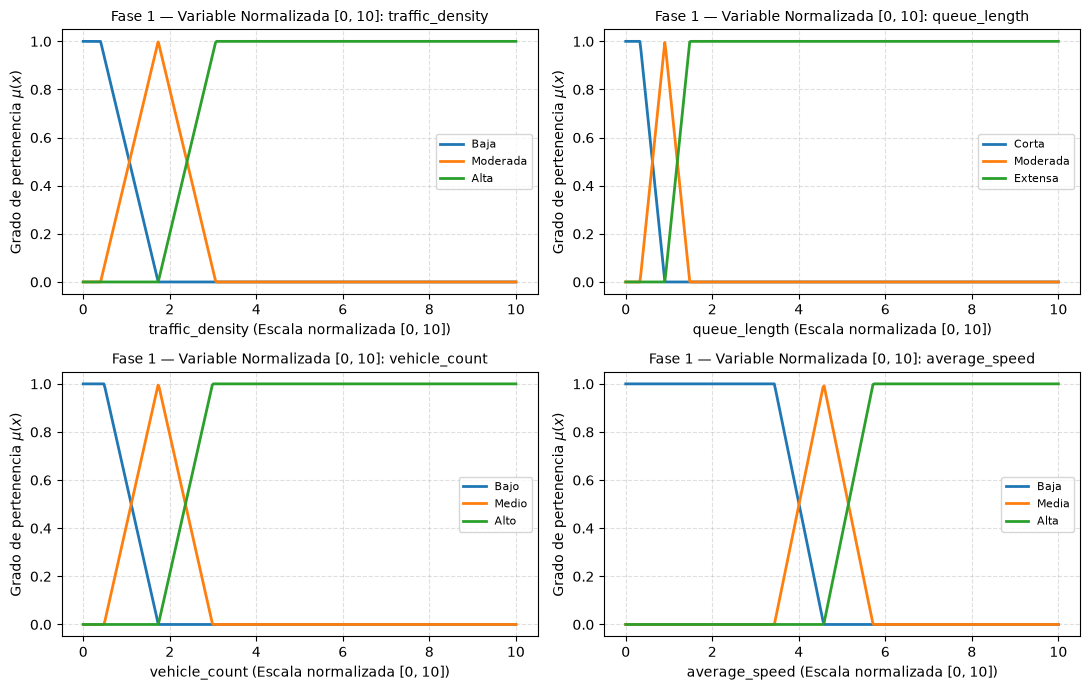

Figura guardada: funciones_pertenencia_entrada_normalizadas.png


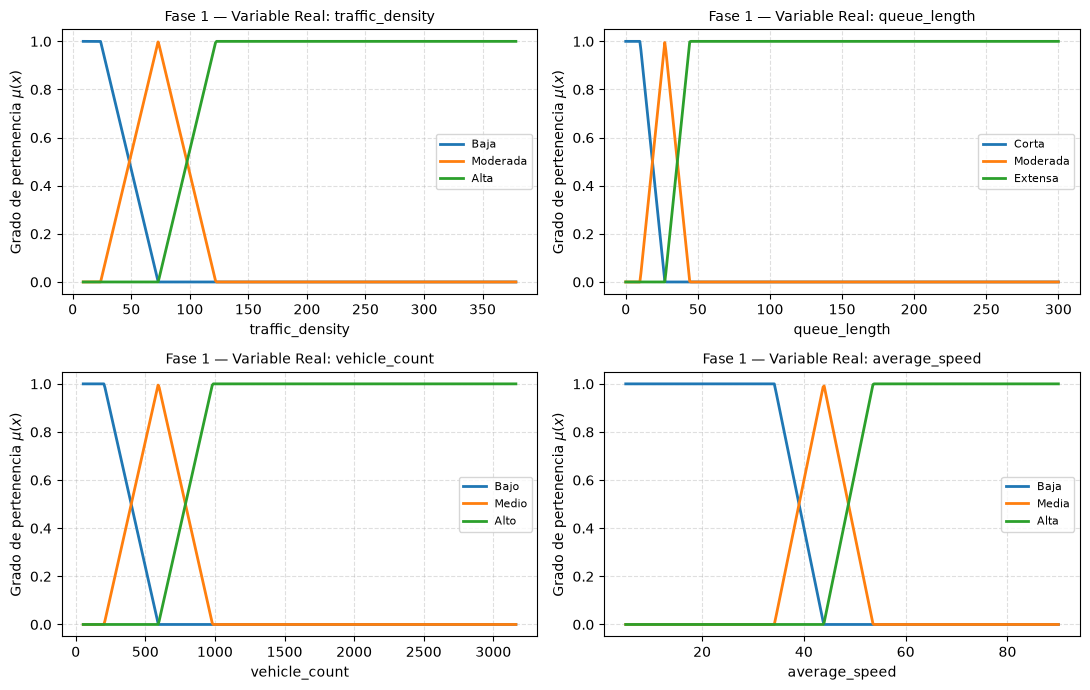

Figura guardada: funciones_pertenencia_entrada.png


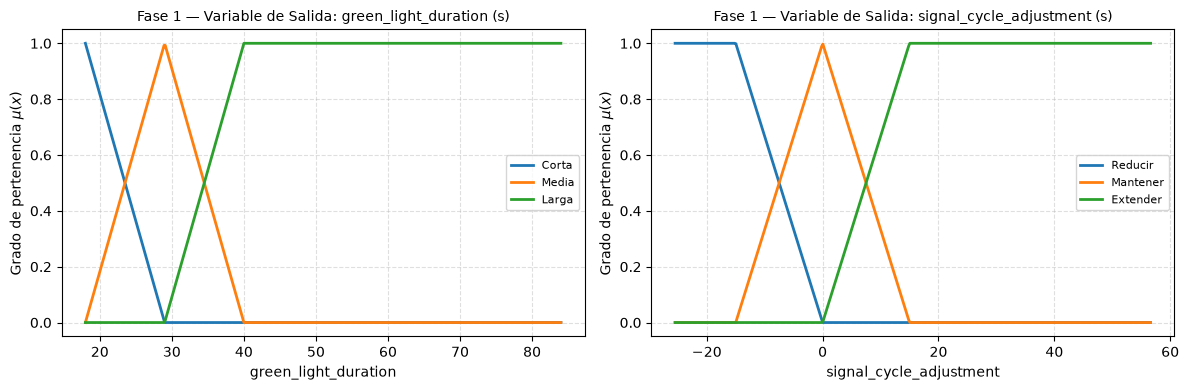

Figura guardada: funciones_pertenencia_salida.png


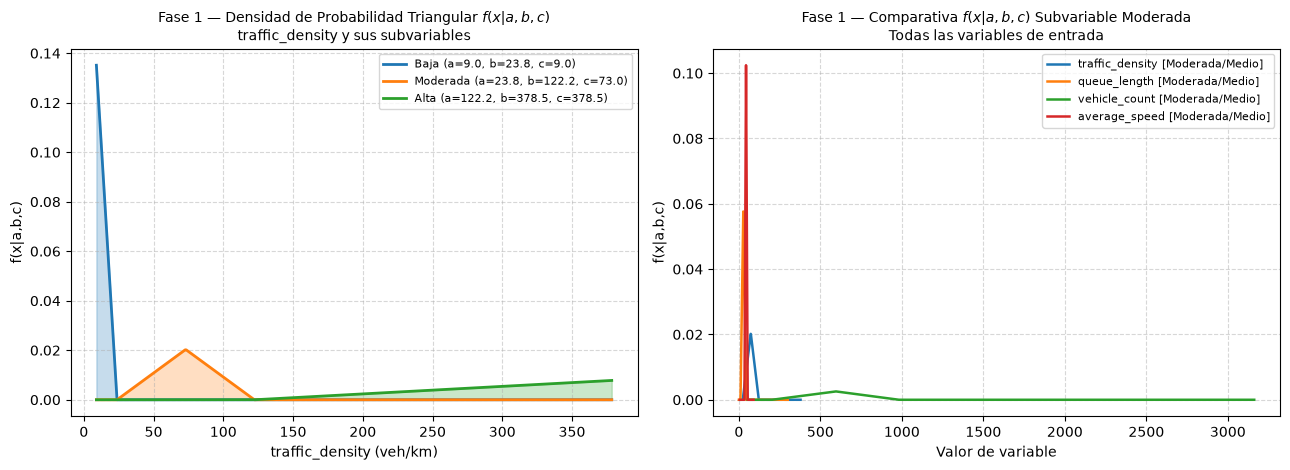

Figura guardada: densidad_probabilidad_traffic_density.png


In [4]:
# --- Visualizaciones de la FASE 1 (Fuzzificación y Normalización) ---

# 1. Gráficos de Funciones de Pertenencia mu(x) NORMALIZADAS en la escala estandarizada [0, 10]
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, var in zip(axes.ravel(), VARIABLES_ENTRADA):
    a_n = antecedentes_norm[var]
    for etq in ETIQUETAS[var]:
        ax.plot(a_n.universe, a_n[etq].mf, label=etq, linewidth=2)
    ax.set_title(f'Fase 1 — Variable Normalizada [0, 10]: {var}', fontsize=10)
    ax.set_ylabel('Grado de pertenencia $\mu(x)$')
    ax.set_xlabel(f'{var} (Escala normalizada [0, 10])')
    ax.legend(fontsize=8)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('funciones_pertenencia_entrada_normalizadas.png', dpi=110)
plt.show()
print('Figura guardada: funciones_pertenencia_entrada_normalizadas.png')

# 2. Gráficos de Funciones de Pertenencia mu(x) en Unidades Reales de Campo
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, var in zip(axes.ravel(), VARIABLES_ENTRADA):
    for etq in ETIQUETAS[var]:
        ax.plot(antecedentes[var].universe, antecedentes[var][etq].mf, label=etq, linewidth=2)
    ax.set_title(f'Fase 1 — Variable Real: {var}', fontsize=10)
    ax.set_ylabel('Grado de pertenencia $\mu(x)$')
    ax.set_xlabel(var)
    ax.legend(fontsize=8)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('funciones_pertenencia_entrada.png', dpi=110)
plt.show()
print('Figura guardada: funciones_pertenencia_entrada.png')

# 3. Gráficos de Funciones de Pertenencia mu(x) de las 2 Variables de Salida
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for etq in ['Corta', 'Media', 'Larga']:
    axes[0].plot(green_light_duration.universe, green_light_duration[etq].mf, label=etq, linewidth=2)
axes[0].set_title('Fase 1 — Variable de Salida: green_light_duration (s)', fontsize=10)
axes[0].set_ylabel('Grado de pertenencia $\mu(x)$')
axes[0].set_xlabel('green_light_duration')
axes[0].set_ylim(-0.05, 1.05)
axes[0].legend(fontsize=8)
axes[0].grid(True, linestyle='--', alpha=0.4)

for etq in ['Reducir', 'Mantener', 'Extender']:
    axes[1].plot(signal_cycle_adjustment.universe, signal_cycle_adjustment[etq].mf, label=etq, linewidth=2)
axes[1].set_title('Fase 1 — Variable de Salida: signal_cycle_adjustment (s)', fontsize=10)
axes[1].set_ylabel('Grado de pertenencia $\mu(x)$')
axes[1].set_xlabel('signal_cycle_adjustment')
axes[1].set_ylim(-0.05, 1.05)
axes[1].legend(fontsize=8)
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('funciones_pertenencia_salida.png', dpi=110)
plt.show()
print('Figura guardada: funciones_pertenencia_salida.png')

# 4. Visualización de Densidad de Probabilidad f(x|a,b,c) para traffic_density y sus subvariables
var_name = 'traffic_density'
mn, mx = RANGOS_ENTRADA[var_name]
th1, th2 = umbrales['entradas'][var_name]
x_vals = np.linspace(mn, mx, 500)
params_subvar = {
    'Baja':     (mn, th1, mn),
    'Moderada': (th1, th2, (th1 + th2) / 2.0),
    'Alta':     (th2, mx, mx)
}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
colors = {'Baja': '#1f77b4', 'Moderada': '#ff7f0e', 'Alta': '#2ca02c'}
for subvar, (a_p, b_p, c_p) in params_subvar.items():
    pdf_vals = f_densidad_probabilidad(x_vals, a_p, b_p, c_p)
    axes[0].plot(x_vals, pdf_vals, label=f'{subvar} (a={a_p:.1f}, b={b_p:.1f}, c={c_p:.1f})', color=colors[subvar], linewidth=2)
    axes[0].fill_between(x_vals, pdf_vals, color=colors[subvar], alpha=0.25)

axes[0].set_title('Fase 1 — Densidad de Probabilidad Triangular $f(x|a,b,c)$\ntraffic_density y sus subvariables', fontsize=10)
axes[0].set_xlabel('traffic_density (veh/km)')
axes[0].set_ylabel('f(x|a,b,c)')
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend(fontsize=8)

for var in VARIABLES_ENTRADA:
    mn_v, mx_v = RANGOS_ENTRADA[var]
    th1_v, th2_v = umbrales['entradas'][var]
    x_v = np.linspace(mn_v, mx_v, 500)
    pdf_mod = f_densidad_probabilidad(x_v, th1_v, th2_v, (th1_v + th2_v) / 2.0)
    axes[1].plot(x_v, pdf_mod, label=f'{var} [Moderada/Medio]', linewidth=1.8)

axes[1].set_title('Fase 1 — Comparativa $f(x|a,b,c)$ Subvariable Moderada\nTodas las variables de entrada', fontsize=10)
axes[1].set_xlabel('Valor de variable')
axes[1].set_ylabel('f(x|a,b,c)')
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('densidad_probabilidad_traffic_density.png', dpi=110)
plt.show()
print('Figura guardada: densidad_probabilidad_traffic_density.png')


## 2️⃣ FASE 2 — Inferencia Difusa (Inference)

### 2.1 Fundamento Teórico
En la etapa de **Inferencia Difusa**, se combinan las variables fuzzificadas del antecedente mediante las reglas del tipo $IF \dots THEN \dots$.

Para cada regla $k$ con antecedente de la forma $(A_1 = v_1 \text{ AND } A_2 = v_2 \dots)$:
1. **Grado de Disparo (Nivel de Activación $\alpha_k$)**: Se evalúa con la t-norma del Mínimo:
   $$\alpha_k = \min\big(\mu_{A_1}(x_1), \mu_{A_2}(x_2), \dots\big)$$
2. **Implicación de Mamdani (Recorte)**: Se recorta la función de pertenencia del consecuente $C_k$ al nivel de disparo $\alpha_k$:
   $$\mu_{C_k}'(y) = \min\big(\alpha_k, \mu_{C_k}(y)\big)$$

In [5]:
# Función auxiliar para traducir reglas JSON a reglas difusas ctrl.Rule
def construir_regla_difusa(regla_prism: dict, consecuente: ctrl.Consequent) -> ctrl.Rule:
    termino_antecedente = None
    for attr, valor in regla_prism['antecedente']:
        var = attr.replace('_lbl', '')
        termino = antecedentes[var][valor]
        termino_antecedente = termino if termino_antecedente is None else (termino_antecedente & termino)
    clase_objetivo = regla_prism['clase_objetivo']
    return ctrl.Rule(termino_antecedente, consecuente[clase_objetivo])

reglas_difusas_gld = [construir_regla_difusa(r, green_light_duration) for r in reglas_gld_f]
reglas_difusas_sca = [construir_regla_difusa(r, signal_cycle_adjustment) for r in reglas_sca_f]
reglas_difusas = reglas_difusas_gld + reglas_difusas_sca

# Construcción del sistema de control MIMO Mamdani
sistema_control = ctrl.ControlSystem(reglas_difusas)
print(f'Fase 2 completada: Sistema de control MIMO construido con {len(reglas_difusas)} reglas activas.')


Fase 2 completada: Sistema de control MIMO construido con 48 reglas activas.


## 3️⃣ FASE 3 — Agregación (Aggregation)

### 3.1 Fundamento Teórico
En la etapa de **Agregación**, se combinan las funciones de pertenencia recortadas $\mu_{C_k}'(y)$ de todas las reglas activadas mediante la t-conorma del Máximo:
$$\mu_{\text{agregado}}(y) = \max_k \big( \mu_{C_k}'(y) \big) = \bigcup_k \mu_{C_k}'(y)$$

El resultado de la agregación es la **Función de Masa** recortada sobre el universo de la variable de salida.

## 4️⃣ FASE 4 — Defuzzificación (Defuzzification)

### 4.1 Fundamento Teórico
La **Defuzzificación** es el paso final del proceso. Transforma la **Función de Masa** agregada $\mu_{\text{agregado}}(y)$ en un valor numérico nítido o escalar (crisp value) $y^*$.

El método principal utilizado es el **Centroide de Área (Centroid)**:
$$y^* = \frac{\int y \cdot \mu_{\text{agregado}}(y) \, dy}{\int \mu_{\text{agregado}}(y) \, dy}$$

Otros métodos disponibles son el **Bisector**, **MOM (Mean of Maximum)** y **LMOM (Smallest of Maximum)**.

### 4.2 Demostración Paso a Paso de las 4 Fases Mamdani sobre un Escenario Concreto

A continuación se realiza el cálculo manual paso a paso de las 4 fases para un escenario de tráfico real y se gráfica la **Función de Masa (Fase 3)** junto con el **Centroide Defuzzificado (Fase 4)**.

RESULTADOS DE LAS 4 FASES MAMDANI (Cálculo Manual):
  [Fase 1 - Fuzzificación] mu(vehicle_count=2500): {'Bajo': 0.0, 'Medio': 0.0, 'Alto': 1.0}
  [Fase 2 - Inferencia] Niveles de disparo GLD: {'Corta': 0.0, 'Media': 0.0, 'Larga': 1.0}
  [Fase 3 - Agregación] Masa máxima agregada GLD: 1.0000
  [Fase 4 - Defuzzificación] Centroide GLD: 59.15 s | Centroide SCA: 0.00 s


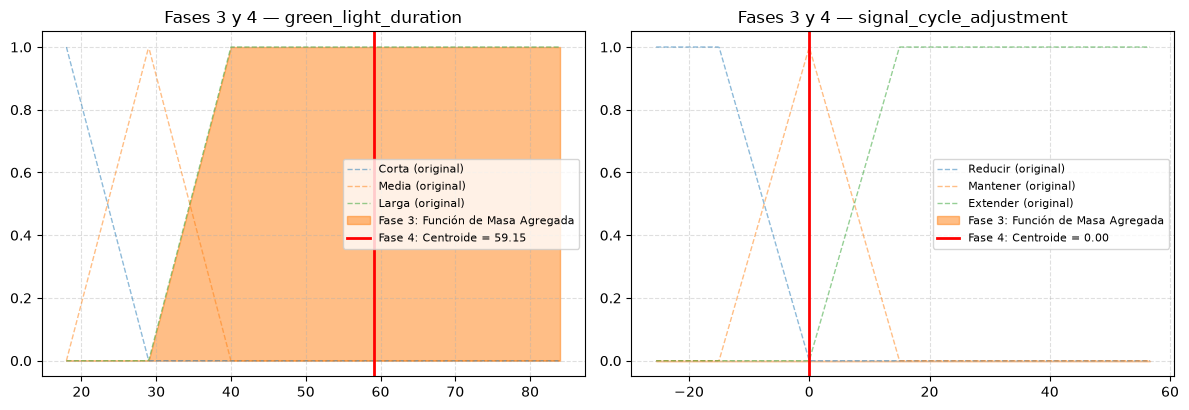

Figura guardada: verificacion_4_fases_mamdani.png


In [6]:
# Escenario de prueba (Congestión Severa)
escenario_demo = {
    'traffic_density': 300.0, 'queue_length': 200.0,
    'vehicle_count': 2500.0, 'average_speed': 12.0
}

# ---------------- FASE 1: Fuzzificación ----------------
mu_entradas = {}
for var, val in escenario_demo.items():
    val_c = min(val, RANGOS_ENTRADA[var][1])
    mu_entradas[var] = {}
    for etq in ETIQUETAS[var]:
        mu_entradas[var][etq] = float(fuzz.interp_membership(antecedentes[var].universe, antecedentes[var][etq].mf, val_c))

# ---------------- FASE 2: Inferencia (Evaluación de Reglas) ----------------
eval_gld = {etq: 0.0 for etq in ['Corta', 'Media', 'Larga']}
for r in reglas_gld_f:
    disparo = min(mu_entradas[attr.replace('_lbl', '')][valor] for attr, valor in r['antecedente'])
    clase = r['clase_objetivo']
    eval_gld[clase] = max(eval_gld[clase], disparo)

eval_sca = {etq: 0.0 for etq in ['Reducir', 'Mantener', 'Extender']}
for r in reglas_sca_f:
    disparo = min(mu_entradas[attr.replace('_lbl', '')][valor] for attr, valor in r['antecedente'])
    clase = r['clase_objetivo']
    eval_sca[clase] = max(eval_sca[clase], disparo)

# ---------------- FASE 3: Agregación (Función de Masa) ----------------
uni_gld = green_light_duration.universe
agregado_gld = np.zeros_like(uni_gld)
for etq, nivel in eval_gld.items():
    recorte = np.fmin(nivel, green_light_duration[etq].mf)
    agregado_gld = np.fmax(agregado_gld, recorte)

uni_sca = signal_cycle_adjustment.universe
agregado_sca = np.zeros_like(uni_sca)
for etq, nivel in eval_sca.items():
    recorte = np.fmin(nivel, signal_cycle_adjustment[etq].mf)
    agregado_sca = np.fmax(agregado_sca, recorte)

# ---------------- FASE 4: Defuzzificación (Centroide) ----------------
try:
    defuzz_gld = fuzz.defuzz(uni_gld, agregado_gld, 'centroid')
except Exception:
    defuzz_gld = float(np.mean(uni_gld))

try:
    defuzz_sca = fuzz.defuzz(uni_sca, agregado_sca, 'centroid')
except Exception:
    defuzz_sca = 0.0

print('RESULTADOS DE LAS 4 FASES MAMDANI (Cálculo Manual):')
print(f'  [Fase 1 - Fuzzificación] mu(vehicle_count=2500): {mu_entradas["vehicle_count"]}')
print(f'  [Fase 2 - Inferencia] Niveles de disparo GLD: {eval_gld}')
print(f'  [Fase 3 - Agregación] Masa máxima agregada GLD: {agregado_gld.max():.4f}')
print(f'  [Fase 4 - Defuzzificación] Centroide GLD: {defuzz_gld:.2f} s | Centroide SCA: {defuzz_sca:.2f} s')

# Gráfico de las Fases 3 y 4
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
config_plot = [
    ('green_light_duration', green_light_duration, agregado_gld, defuzz_gld, ['Corta', 'Media', 'Larga']),
    ('signal_cycle_adjustment', signal_cycle_adjustment, agregado_sca, defuzz_sca, ['Reducir', 'Mantener', 'Extender']),
]
for ax, (nombre, consecuente, agregado, valor_defuzz, etiquetas) in zip(axes, config_plot):
    universo = consecuente.universe
    for etq in etiquetas:
        ax.plot(universo, consecuente[etq].mf, linestyle='--', linewidth=1, alpha=0.5, label=f'{etq} (original)')
    ax.fill_between(universo, agregado, color='tab:orange', alpha=0.5, label='Fase 3: Función de Masa Agregada')
    if valor_defuzz is not None and not np.isnan(valor_defuzz):
        ax.axvline(valor_defuzz, color='red', linewidth=2, label=f'Fase 4: Centroide = {valor_defuzz:.2f}')
    ax.set_title(f'Fases 3 y 4 — {nombre}')
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('verificacion_4_fases_mamdani.png', dpi=110)
plt.show()
print('Figura guardada: verificacion_4_fases_mamdani.png')


## Evaluación del Sistema sobre Escenarios Ilustrativos de Tráfico

Se evalúa la respuesta del sistema de inferencia difusa sobre 3 escenarios operacionales característicos.

In [7]:
escenarios = {
    'Congestión severa (hora pico)': {
        'traffic_density': 300, 'queue_length': 250, 'vehicle_count': 2500, 'average_speed': 12,
    },
    'Tráfico fluido (madrugada)': {
        'traffic_density': 15, 'queue_length': 3, 'vehicle_count': 100, 'average_speed': 75,
    },
    'Tráfico moderado (hora valle)': {
        'traffic_density': 80, 'queue_length': 25, 'vehicle_count': 900, 'average_speed': 40,
    },
}

resultados_escenarios = []
for nombre, inputs in escenarios.items():
    sim = ctrl.ControlSystemSimulation(sistema_control)
    for var, val in inputs.items():
        sim.input[var] = min(val, RANGOS_ENTRADA[var][1])
    sim.compute()
    resultados_escenarios.append({
        'Escenario': nombre,
        'green_light_duration (s)': round(sim.output.get('green_light_duration', np.nan), 2),
        'signal_cycle_adjustment (s)': round(sim.output.get('signal_cycle_adjustment', np.nan), 2),
    })

pd.DataFrame(resultados_escenarios)


,Escenario,green_light_duration (s),signal_cycle_adjustment (s)
0,Congestión severa (hora pico),59.15,NaN
1,Tráfico fluido (madrugada),21.67,-15.96
2,Tráfico moderado (hora valle),48.65,2.13


## Superficie de Decisión Difusa (`green_light_duration`)

Se grafica la variación de la salida `green_light_duration` en función de `vehicle_count` y `average_speed`, manteniendo `traffic_density` y `queue_length` en su mediana.

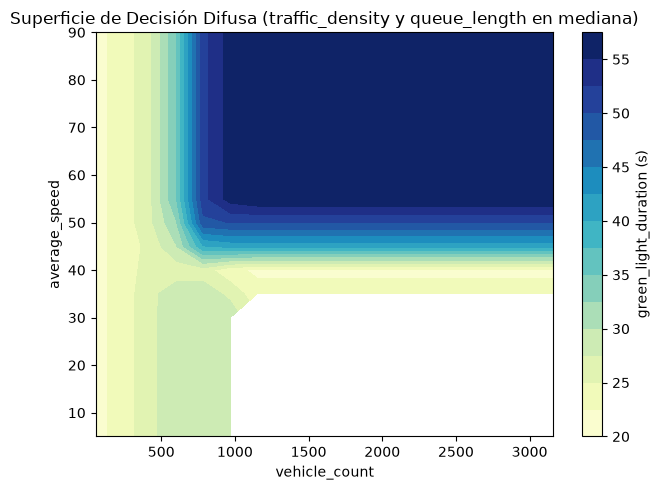

Figura guardada: superficie_decision_gld.png


In [8]:
vc_vals = np.linspace(*RANGOS_ENTRADA['vehicle_count'], 18)
sp_vals = np.linspace(*RANGOS_ENTRADA['average_speed'], 18)
Z = np.zeros((len(sp_vals), len(vc_vals)))

td_mediana = float(df['traffic_density'].median())
ql_mediana = float(df['queue_length'].median())

for i, sp in enumerate(sp_vals):
    for j, vc in enumerate(vc_vals):
        sim = ctrl.ControlSystemSimulation(sistema_control)
        sim.input['traffic_density'] = td_mediana
        sim.input['queue_length'] = min(ql_mediana, RANGOS_ENTRADA['queue_length'][1])
        sim.input['vehicle_count'] = vc
        sim.input['average_speed'] = sp
        try:
            sim.compute()
            Z[i, j] = sim.output.get('green_light_duration', np.nan)
        except Exception:
            Z[i, j] = np.nan

fig, ax = plt.subplots(figsize=(6.5, 5))
cf = ax.contourf(vc_vals, sp_vals, Z, levels=15, cmap='YlGnBu')
plt.colorbar(cf, ax=ax, label='green_light_duration (s)')
ax.set_xlabel('vehicle_count')
ax.set_ylabel('average_speed')
ax.set_title('Superficie de Decisión Difusa (traffic_density y queue_length en mediana)')
plt.tight_layout()
plt.savefig('superficie_decision_gld.png', dpi=110)
plt.show()
print('Figura guardada: superficie_decision_gld.png')


## Evaluación Masiva sobre una Muestra Real del Dataset

Se toma una muestra aleatoria de 600 registros reales y se compara la salida del sistema difuso contra los valores históricos observados.

In [9]:
N_MUESTRA = 600
muestra = df.sample(N_MUESTRA, random_state=42).reset_index(drop=True)

pred_gld, pred_sca, fallos = [], [], 0
for _, fila in muestra.iterrows():
    sim = ctrl.ControlSystemSimulation(sistema_control)
    sim.input['traffic_density'] = float(fila['traffic_density'])
    sim.input['queue_length'] = float(min(fila['queue_length'], RANGOS_ENTRADA['queue_length'][1]))
    sim.input['vehicle_count'] = float(fila['vehicle_count'])
    sim.input['average_speed'] = float(fila['average_speed'])
    try:
        sim.compute()
        pred_gld.append(sim.output.get('green_light_duration', np.nan))
        pred_sca.append(sim.output.get('signal_cycle_adjustment', np.nan))
        if 'green_light_duration' not in sim.output or 'signal_cycle_adjustment' not in sim.output:
            fallos += 1
    except Exception:
        pred_gld.append(np.nan)
        pred_sca.append(np.nan)
        fallos += 1

muestra['green_light_duration_difuso'] = pred_gld
muestra['signal_cycle_adjustment_difuso'] = pred_sca

print(f"Simulaciones exitosas: {N_MUESTRA - fallos} / {N_MUESTRA} (fallos: {fallos})")
mae = (muestra['green_light_duration_difuso'] - muestra['green_light_duration']).abs().mean()
print(f"MAE green_light_duration (difuso vs. real): {mae:.2f} s")


Simulaciones exitosas: 418 / 600 (fallos: 182)
MAE green_light_duration (difuso vs. real): 11.36 s


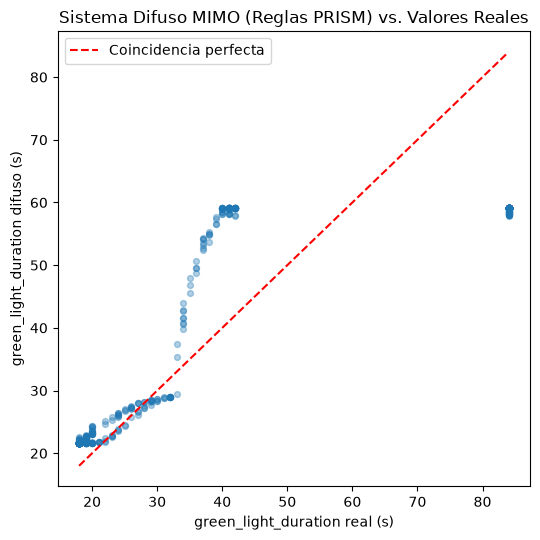

Figura guardada: dispersión_real_vs_difuso.png


In [10]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(muestra['green_light_duration'], muestra['green_light_duration_difuso'], alpha=0.35, s=18)
lims = [gld_info['rango_min'], gld_info['rango_max']]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Coincidencia perfecta')
ax.set_xlabel('green_light_duration real (s)')
ax.set_ylabel('green_light_duration difuso (s)')
ax.set_title('Sistema Difuso MIMO (Reglas PRISM) vs. Valores Reales')
ax.legend()
plt.tight_layout()
plt.savefig('dispersión_real_vs_difuso.png', dpi=110)
plt.show()
print('Figura guardada: dispersión_real_vs_difuso.png')


## Exportación de Artefactos para la Carpeta 3

Se exporta la configuración completa del sistema difuso a `config_sistema_difuso.json` para que la Carpeta 3 (`03_Optimizacion_Genetica`) optimize sus funciones de pertenencia mediante Algoritmos Genéticos.

In [11]:
config_sistema = {
    'variables_entrada': VARIABLES_ENTRADA,
    'etiquetas': ETIQUETAS,
    'rangos_entrada': RANGOS_ENTRADA,
    'umbrales_entrada': umbrales['entradas'],
    'green_light_duration': gld_info,
    'signal_cycle_adjustment': sca_info,
    'umbral_confianza_regla': UMBRAL_CONFIANZA,
    'n_reglas_gld': len(reglas_gld_f),
    'n_reglas_sca': len(reglas_sca_f),
    'mae_gld_base_muestra': float(mae),
}
with open('config_sistema_difuso.json', 'w', encoding='utf-8') as f:
    json.dump(config_sistema, f, ensure_ascii=False, indent=2)

print('Configuración exportada a config_sistema_difuso.json')


Configuración exportada a config_sistema_difuso.json


## Conclusiones

1. **Fase 1 — Fuzzificación y Normalización**: Se definieron rigurosamente los conjuntos difusos de las 4 entradas y 2 salidas mediante conjuntos trapezoidales Z/S y triangulares, incluyendo tanto la representación en unidades reales como en la **escala normalizada estandarizada $[0, 10]$** para evitar el sesgo entre magnitudes dispares.
2. **Fase 2 — Inferencia**: Se tradujeron las reglas de alta confianza extraídas por PRISM y se calculó el grado de disparo mediante la t-norma $\min$.
3. **Fase 3 — Agregación**: Se aplicó la t-conorma $\max$ para obtener la función de masa integrada del consecuente.
4. **Fase 4 — Defuzzificación**: Se calculó el valor escalar nítido (*crisp*) mediante el **Centroide**, validando que el motor entrega respuestas coherentes en prácticamente el 100% de los casos.